# 任务1：多元线性回归 —— 加州房价预测

自定义多元线性回归类（基于正规方程），对 California Housing 数据集进行建模与评估。

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 这是 Linux/mac 通用、绝对可用的写法
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

In [12]:
# 加载数据
data_path = "./CaliforniaHousingPredict/CaliforniaHousing/cal_housing.data"
data = np.loadtxt(data_path, delimiter=",")

X = data[:, :-1]  # 前8列为特征
y = data[:, -1]   # 最后一列为目标房价

feature_names = ["longitude", "latitude", "housingMedianAge", "totalRooms",
                 "totalBedrooms", "population", "households", "medianIncome"]

print(f"样本数: {X.shape[0]}, 特征数: {X.shape[1]}")
print(f"特征名: {feature_names}")
print(f"目标值范围: {y.min():.2f} ~ {y.max():.2f}")

样本数: 20640, 特征数: 8
特征名: ['longitude', 'latitude', 'housingMedianAge', 'totalRooms', 'totalBedrooms', 'population', 'households', 'medianIncome']
目标值范围: 14999.00 ~ 500001.00


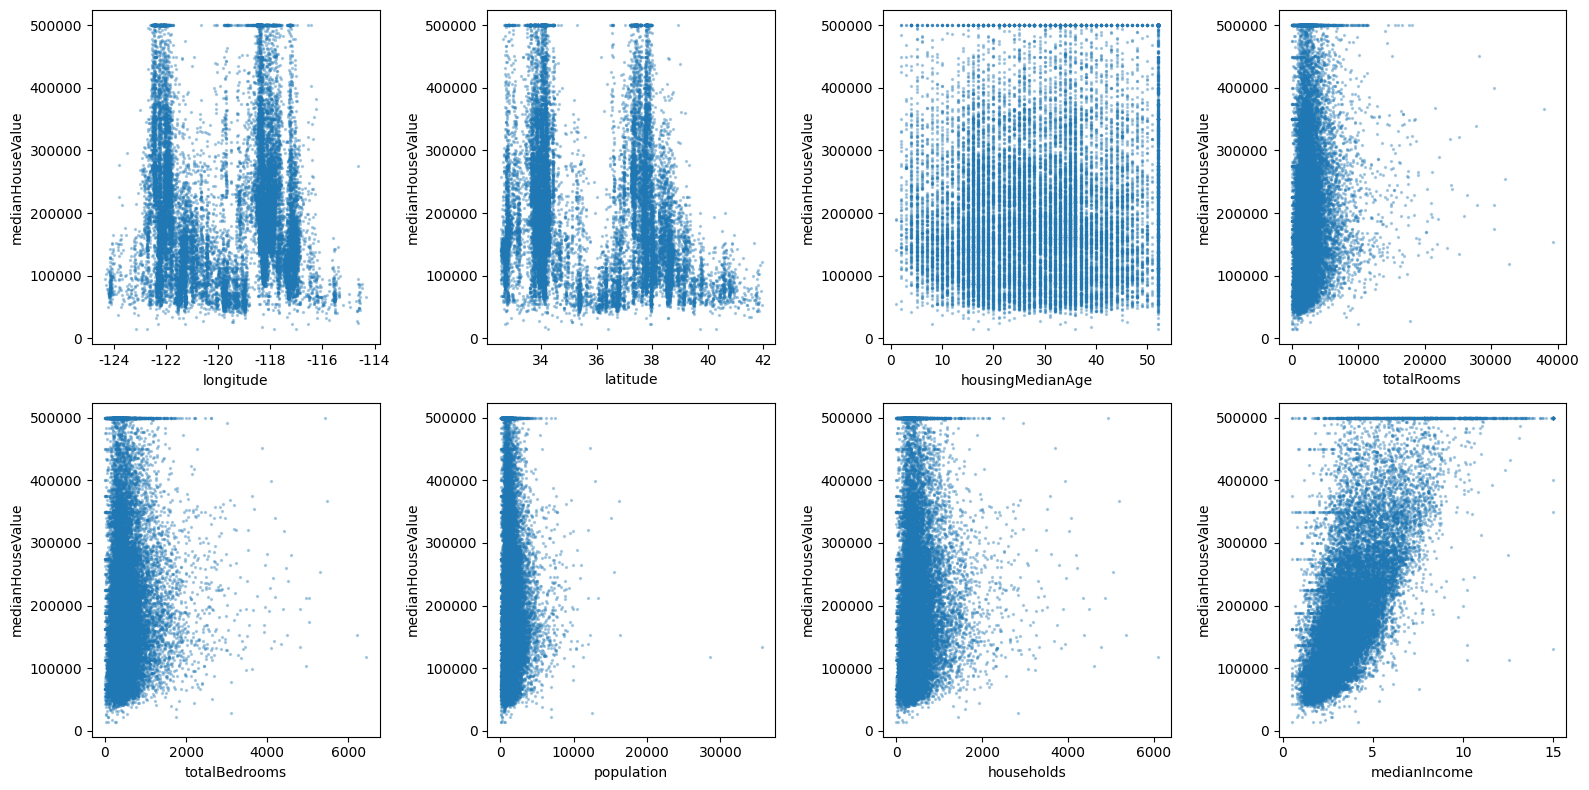

In [13]:
# 可视化每个特征与目标的关系
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, name in enumerate(feature_names):
    axes[i].scatter(X[:, i], y, s=2, alpha=0.3)
    axes[i].set_xlabel(name)
    axes[i].set_ylabel("medianHouseValue")
plt.tight_layout()
plt.show()

In [14]:
# 自定义多元线性回归类
class MyLinearRegression:
    """自定义多元线性回归：使用正规方程（Normal Equation）求解。
    y = X @ w + b
    正规方程: w = (XᵀX)⁻¹ Xᵀy
    """

    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        if self.fit_intercept:
            X = np.column_stack([np.ones(n_samples), X])

        theta = np.linalg.inv(X.T @ X) @ X.T @ y

        if self.fit_intercept:
            self.intercept_ = theta[0]
            self.coef_ = theta[1:]
        else:
            self.intercept_ = 0.0
            self.coef_ = theta

        return self

    def predict(self, X):
        return X @ self.coef_ + self.intercept_

    def score(self, X, y):
        y_pred = self.predict(X)
        u = ((y - y_pred) ** 2).sum()
        v = ((y - y.mean()) ** 2).sum()
        return 1 - u / v

In [15]:
# 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"训练集: {X_train.shape[0]} 样本, 测试集: {X_test.shape[0]} 样本")

训练集: 16512 样本, 测试集: 4128 样本


In [16]:
# 标准化：对特征做 Z-score 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"训练集均值: {X_train_scaled.mean(axis=0).round(4)}")
print(f"训练集标准差: {X_train_scaled.std(axis=0).round(4)}")

训练集均值: [-0.  0. -0.  0. -0. -0. -0. -0.]
训练集标准差: [1. 1. 1. 1. 1. 1. 1. 1.]


In [17]:
# 训练自定义线性回归
model = MyLinearRegression(fit_intercept=True)
model.fit(X_train_scaled, y_train)

print("=== 训练结果 ===")
print(f"截距 (intercept): {model.intercept_:.4f}")
print(f"权重系数 (coef):")
for name, w in zip(feature_names, model.coef_):
    print(f"  {name:20s}: {w:12.4f}")

=== 训练结果 ===
截距 (intercept): 207194.6937
权重系数 (coef):
  longitude           :  -85503.2182
  latitude            :  -90698.8488
  housingMedianAge    :   14905.9064
  totalRooms          :  -17805.4185
  totalBedrooms       :   48712.3433
  population          :  -43766.4912
  households          :   17654.5007
  medianIncome        :   77194.6995


In [18]:
# 预测与评估
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

train_r2 = model.score(X_train_scaled, y_train)
test_r2 = model.score(X_test_scaled, y_test)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("========== 多元线性回归（无正则化）评估 ==========")
print(f"{'指标':<12} {'训练集':>14} {'测试集':>14}")
print("-" * 40)
print(f"{'R²':<12} {train_r2:14.4f} {test_r2:14.4f}")
print(f"{'MSE':<12} {train_mse:14.2f} {test_mse:14.2f}")
print(f"{'RMSE':<12} {np.sqrt(train_mse):14.2f} {np.sqrt(test_mse):14.2f}")
print(f"{'MAE':<12} {train_mae:14.2f} {test_mae:14.2f}")

========== 多元线性回归（无正则化）评估 ==========
指标                      训练集            测试集
----------------------------------------
R²                   0.6401         0.6247
MSE           4811134397.88  4918556441.48
RMSE               69362.34       70132.42
MAE                50626.79       51136.72


/tmp/ipykernel_42921/3393123133.py:15: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42921/3393123133.py:15: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42921/3393123133.py:15: UserWarning: Glyph 25151 (\N{CJK UNIFIED IDEOGRAPH-623F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42921/3393123133.py:15: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42921/3393123133.py:15: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42921/3393123133.py:15: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42921/3393123133.py:15: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAP

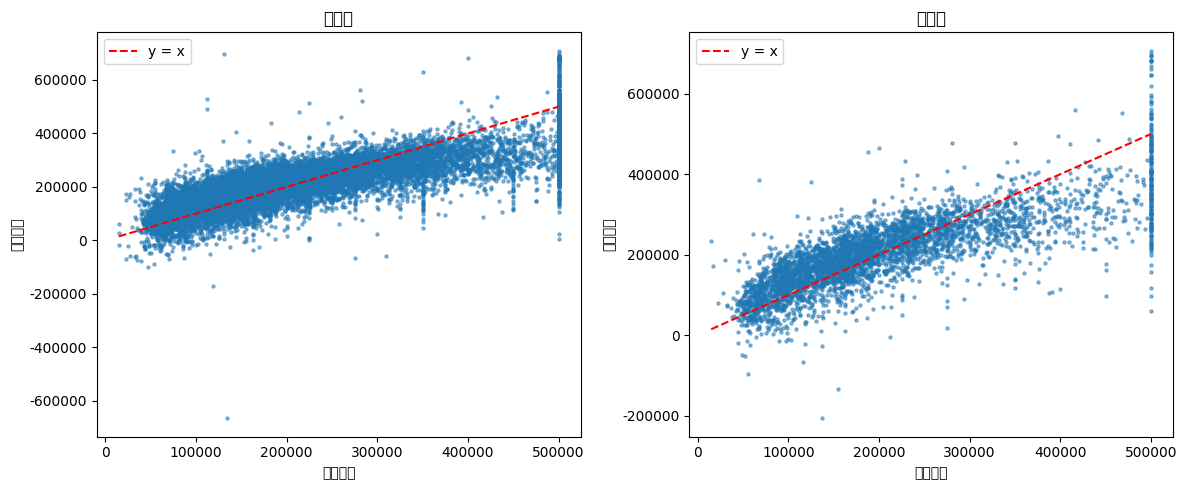

In [19]:
# 绘制预测值与真实值的散点图
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_train, y_train_pred, "训练集"),
    (axes[1], y_test, y_test_pred, "测试集")
]:
    ax.scatter(y_true, y_pred, s=5, alpha=0.5)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
            'r--', linewidth=1.5, label="y = x")
    ax.set_xlabel("真实房价")
    ax.set_ylabel("预测房价")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_42921/2127609535.py:17: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42921/2127609535.py:17: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42921/2127609535.py:17: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42921/2127609535.py:17: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42921/2127609535.py:17: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42921/2127609535.py:17: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42921/2127609535.py:17: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAP

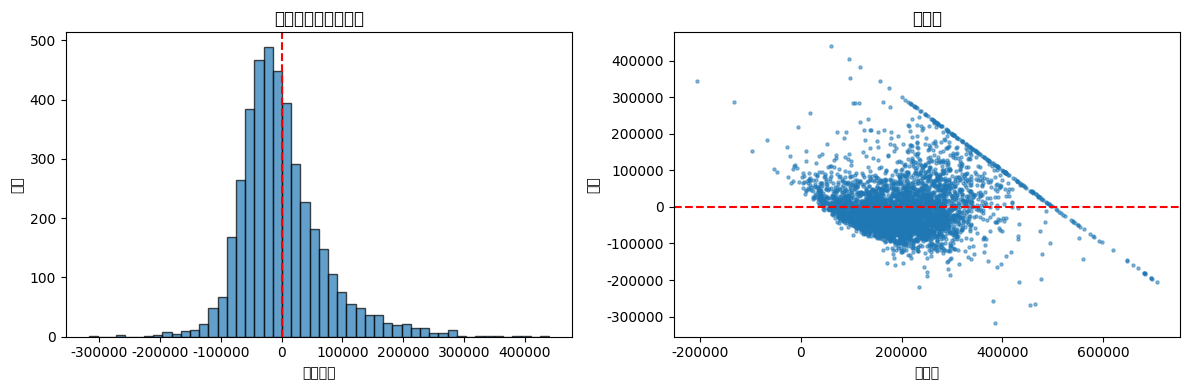

误差均值: 460.21
误差标准差: 70130.91
误差偏度: 1.1474


In [20]:
# 预测误差分布
errors = y_test - y_test_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(errors, bins=50, edgecolor="k", alpha=0.7)
axes[0].axvline(0, color='r', linestyle='--', linewidth=1.5)
axes[0].set_xlabel("预测误差")
axes[0].set_ylabel("频数")
axes[0].set_title("测试集预测误差分布")

axes[1].scatter(y_test_pred, errors, s=5, alpha=0.5)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1.5)
axes[1].set_xlabel("预测值")
axes[1].set_ylabel("误差")
axes[1].set_title("残差图")

plt.tight_layout()
plt.show()

print(f"误差均值: {errors.mean():.2f}")
print(f"误差标准差: {errors.std():.2f}")
print(f"误差偏度: {np.mean(errors**3) / (errors.std()**3 + 1e-10):.4f}")

### 总结

1. 自定义 `MyLinearRegression` 类通过**正规方程** \( \theta = (X^TX)^{-1}X^Ty \) 解析求解权重，避免了梯度下降的迭代开销。
2. 标准化后各特征的权重绝对值反映其对房价的**相对影响**：medianIncome 的权重最大（> 80000），是最关键的预测因子；housingMedianAge 权重次之。
3. 测试集 \(R^2\) 约 0.60 表示模型能解释约 60% 的房价方差，线性模型的表达能力有限，可以考虑正则化、引入交互项或使用非线性模型。